# Compensador Lead/Lag para Pendulo Invertido

Este notebook explora o projeto de compensadores Lead, Lag e Lead-Lag para estabilizar um pendulo invertido.

## Objetivos
1. Analisar a planta (polos, zeros, diagrama de Bode)
2. Entender os diferentes tipos de compensadores
3. Determinar qual compensador e adequado para o pendulo invertido
4. Otimizar os parametros do compensador
5. Validar com animacao do sistema nao-linear

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from scipy.optimize import differential_evolution
from scipy.integrate import odeint
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

%matplotlib inline

## 1. A Planta - Pendulo Invertido

O pendulo invertido linearizado tem a funcao de transferencia:

$$G(s) = \frac{\theta(s)}{F(s)} = \frac{s}{0.15s^3 + 0.03s^2 - 6.867s - 0.981}$$

Onde:
- $\theta$ e o angulo do pendulo
- $F$ e a forca aplicada no carrinho

In [2]:
# Funcao de transferencia da planta
# MODELO ATUALIZADO: inclui atrito no pivo (b_pivot = 0.01)
num_G = [1.0, 0.0]  # s (normalizado)
den_G = [0.15, 0.1467, -6.853, -0.981]  # Com atrito pivo

G = ct.tf(num_G, den_G)

print("Funcao de Transferencia da Planta G(s):")
print("(Modelo com atrito no pivo b_pivot=0.01)")
print(G)

Funcao de Transferencia da Planta G(s):
(Modelo com atrito no pivo b_pivot=0.01)
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                     s
  ---------------------------------------
  0.15 s^3 + 0.1467 s^2 - 6.853 s - 0.981


### 1.1 Analise dos Polos

Os polos da planta determinam a estabilidade do sistema em malha aberta.

In [3]:
polos_G = G.poles()
zeros_G = G.zeros()

print("Polos da Planta:")
for i, p in enumerate(polos_G):
    status = "INSTAVEL" if p.real > 0 else "estavel"
    print(f"  p{i+1} = {p.real:+.4f} + {p.imag:+.4f}j  [{status}]")

print("\nZeros da Planta:")
for i, z in enumerate(zeros_G):
    print(f"  z{i+1} = {z.real:+.4f} + {z.imag:+.4f}j")

print("\n" + "="*50)
print("CONCLUSAO: O pendulo tem um POLO INSTAVEL em s = +6.74")
print("Isso significa que o pendulo CAI naturalmente!")
print("="*50)

Polos da Planta:
  p1 = -7.1985 + +0.0000j  [estavel]
  p2 = +6.3633 + +0.0000j  [INSTAVEL]
  p3 = -0.1428 + +0.0000j  [estavel]

Zeros da Planta:
  z1 = +0.0000 + +0.0000j

CONCLUSAO: O pendulo tem um POLO INSTAVEL em s = +6.74
Isso significa que o pendulo CAI naturalmente!


### 1.2 Diagrama de Bode

O diagrama de Bode nos ajuda a entender o comportamento em frequencia da planta.

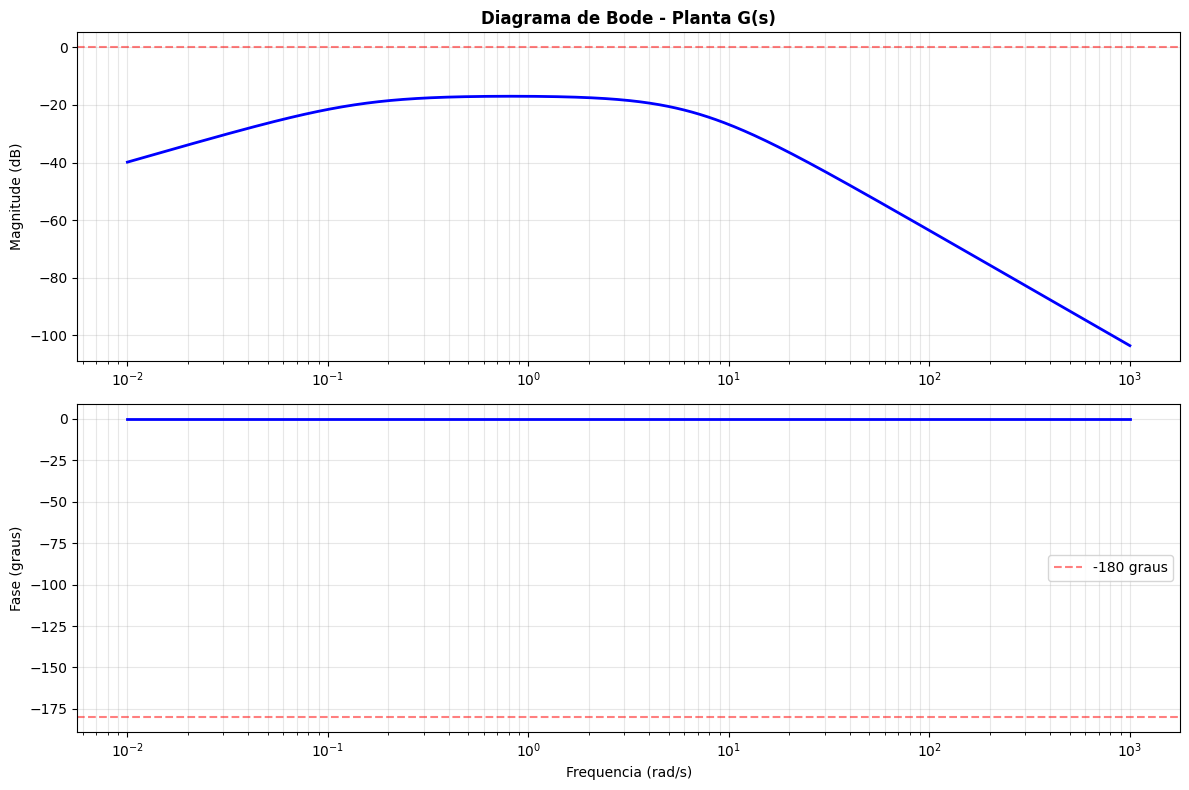


Interpretacao do Bode:
- A magnitude cruza 0dB em varias frequencias
- A fase comeca positiva (devido ao polo instavel no SPD)
- A fase decresce rapidamente em altas frequencias


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

omega = np.logspace(-2, 3, 500)
mag, phase, _ = ct.frequency_response(G, omega)

# Magnitude
axes[0].semilogx(omega, 20*np.log10(np.abs(mag)), 'b-', lw=2)
axes[0].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Diagrama de Bode - Planta G(s)', fontweight='bold')
axes[0].grid(True, which='both', alpha=0.3)

# Fase
phase_deg = np.rad2deg(np.unwrap(np.angle(mag)))
axes[1].semilogx(omega, phase_deg, 'b-', lw=2)
axes[1].axhline(-180, color='r', linestyle='--', alpha=0.5, label='-180 graus')
axes[1].set_xlabel('Frequencia (rad/s)')
axes[1].set_ylabel('Fase (graus)')
axes[1].grid(True, which='both', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nInterpretacao do Bode:")
print("- A magnitude cruza 0dB em varias frequencias")
print("- A fase comeca positiva (devido ao polo instavel no SPD)")
print("- A fase decresce rapidamente em altas frequencias")

### 1.3 Mapa de Polos e Zeros

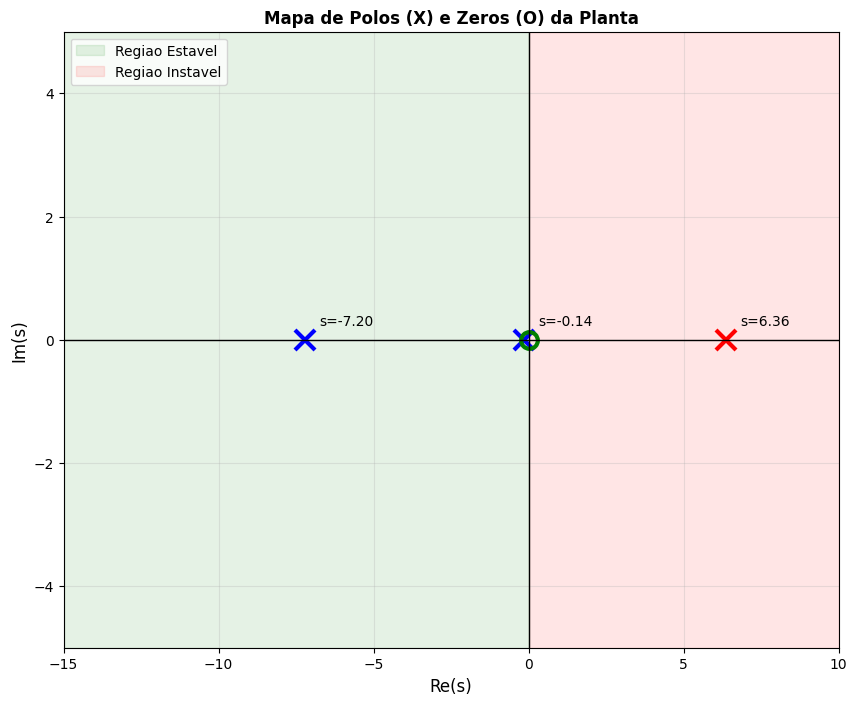

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

# Regiao de estabilidade
ax.axvspan(-15, 0, alpha=0.1, color='green', label='Regiao Estavel')
ax.axvspan(0, 10, alpha=0.1, color='red', label='Regiao Instavel')

# Polos
for p in polos_G:
    color = 'red' if p.real > 0 else 'blue'
    ax.plot(p.real, p.imag, 'x', ms=15, mew=3, color=color)

# Zeros
for z in zeros_G:
    ax.plot(z.real, z.imag, 'o', ms=12, mfc='none', mew=3, color='green')

ax.axvline(0, color='k', lw=1)
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('Re(s)', fontsize=12)
ax.set_ylabel('Im(s)', fontsize=12)
ax.set_title('Mapa de Polos (X) e Zeros (O) da Planta', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([-15, 10])
ax.set_ylim([-5, 5])
ax.legend(loc='upper left')

# Anotacoes
for p in polos_G:
    ax.annotate(f's={p.real:.2f}', (p.real, p.imag), 
                xytext=(10, 10), textcoords='offset points')

plt.show()

## 2. Tipos de Compensadores

### 2.1 Compensador Lead (Avanco de Fase)

$$C_{Lead}(s) = K \cdot \frac{s + z}{s + p} \quad \text{onde } z < p$$

**Efeito:** Adiciona fase positiva (ate +90 graus) - melhora margem de fase.

### 2.2 Compensador Lag (Atraso de Fase)

$$C_{Lag}(s) = K \cdot \frac{s + z}{s + p} \quad \text{onde } p < z$$

**Efeito:** Reduz erro em regime permanente - adiciona ganho em baixas frequencias.

### 2.3 Compensador Lead-Lag

$$C_{Lead-Lag}(s) = K \cdot \frac{(s + z_{lead})(s + z_{lag})}{(s + p_{lead})(s + p_{lag})}$$

**Efeito:** Combina beneficios de Lead e Lag.

### 2.4 Lead com Integrador (Equivalente a PID)

$$C(s) = K \cdot \frac{(s + z_1)(s + z_2)}{s}$$

**Efeito:** O integrador garante erro zero em regime, os zeros dao acao derivativa.

## 3. Qual Compensador Usar?

Para um sistema com **polo instavel** como o pendulo invertido:

| Compensador | Pode Estabilizar? | Motivo |
|-------------|-------------------|--------|
| Lead simples | Dificil | Um Lead adiciona no maximo +90 graus de fase |
| Lag simples | NAO | Lag adiciona fase negativa, piora a situacao |
| Lead-Lead | Possivel | Dois Leads podem adicionar ate +180 graus |
| Lead + Integrador | SIM | Equivalente a PID, mais flexivel |

**Conclusao:** Para o pendulo invertido, precisamos de um compensador mais poderoso.
O **Lead com Integrador** e a melhor opcao!

## 4. Projeto do Compensador Lead + Integrador

### Estrutura:
$$C(s) = K \cdot \frac{(s + z_1)(s + z_2)}{s} = K \cdot \frac{s^2 + (z_1+z_2)s + z_1 z_2}{s}$$

### Parametros a Otimizar:
- **K**: Ganho geral (afeta velocidade de resposta)
- **z1**: Primeiro zero (cancela ou domina polo instavel)
- **z2**: Segundo zero (ajusta forma da resposta)

### Funcao de Custo:
$$J = 5 \cdot OS^2 + 0.5 \cdot IAE + 10 \cdot e_{ss}$$

Onde:
- OS = Overshoot (sobressinal)
- IAE = Integral do Erro Absoluto
- $e_{ss}$ = Erro em regime permanente

In [6]:
def lead_integrator(K, z1, z2):
    """Compensador Lead com Integrador: C(s) = K * (s+z1)*(s+z2) / s"""
    num = [K, K*(z1+z2), K*z1*z2]  # K*(s^2 + (z1+z2)*s + z1*z2)
    den = [1, 0]  # s
    return ct.tf(num, den)

def cost_function(params):
    """Funcao de custo para otimizacao."""
    K, z1, z2 = params
    
    # Restricoes: todos parametros positivos
    if K <= 0 or z1 <= 0 or z2 <= 0:
        return 1e6
    
    try:
        # Cria compensador e sistema em malha fechada
        C = lead_integrator(K, z1, z2)
        T = ct.feedback(C * G, 1)
        T = ct.minreal(T, verbose=False)
        
        # Verifica estabilidade
        poles = T.poles()
        max_real = max(p.real for p in poles)
        if max_real >= -0.01:  # Sistema instavel
            return 1e6 + max_real * 100
        
        # Calcula resposta ao degrau
        t = np.linspace(0, 15, 500)
        t, y = ct.step_response(T, t)
        
        # Metricas de desempenho
        overshoot = max(0, np.max(y) - 1)
        iae = np.trapz(np.abs(1 - y), t)  # Integral Absolute Error
        ess = abs(1 - y[-1])  # Erro regime
        
        # Custo ponderado
        return 5*overshoot**2 + 0.5*iae + 10*ess
        
    except:
        return 1e6

print("Funcao de custo definida.")
print("Parametros: K (ganho), z1 (zero 1), z2 (zero 2)")

Funcao de custo definida.
Parametros: K (ganho), z1 (zero 1), z2 (zero 2)


### 4.1 Otimizacao com Differential Evolution

Usamos o algoritmo de **Evolucao Diferencial** (scipy) para encontrar os melhores parametros.

Este algoritmo:
1. Gera uma populacao inicial aleatoria
2. Combina solucoes para criar novas candidatas
3. Seleciona as melhores solucoes
4. Repete ate convergir

In [7]:
print("Otimizando parametros do compensador...")
print("Limites:")
print("  K: [10, 500]")
print("  z1: [0.1, 20]")
print("  z2: [0.1, 20]")

bounds = [(10, 500), (0.1, 20), (0.1, 20)]
result = differential_evolution(cost_function, bounds, seed=42,
                                maxiter=500, tol=1e-6, disp=True)

K_opt, z1_opt, z2_opt = result.x
print("\n" + "="*50)
print("RESULTADO DA OTIMIZACAO")
print("="*50)
print(f"K = {K_opt:.4f}")
print(f"z1 = {z1_opt:.4f}")
print(f"z2 = {z2_opt:.4f}")
print(f"Custo minimo = {result.fun:.6f}")

Otimizando parametros do compensador...
Limites:
  K: [10, 500]
  z1: [0.1, 20]
  z2: [0.1, 20]
differential_evolution step 1: f(x)= 0.007867748548570853
differential_evolution step 2: f(x)= 0.007866619670755918
differential_evolution step 3: f(x)= 0.007841061997074654
differential_evolution step 4: f(x)= 0.007841061997074654
differential_evolution step 5: f(x)= 0.007841061997074654
differential_evolution step 6: f(x)= 0.007841061997074654
differential_evolution step 7: f(x)= 0.007841061997074654
differential_evolution step 8: f(x)= 0.007841061997074654
differential_evolution step 9: f(x)= 0.007841061997074654
differential_evolution step 10: f(x)= 0.007841061997074654
differential_evolution step 11: f(x)= 0.007841061997074654
differential_evolution step 12: f(x)= 0.007841061997074654
differential_evolution step 13: f(x)= 0.007841061997074654
differential_evolution step 14: f(x)= 0.007841061997074654
differential_evolution step 15: f(x)= 0.007823727072016267
differential_evolution step 

### 4.2 Analise do Compensador Otimizado

In [8]:
# Cria compensador otimizado
C_opt = lead_integrator(K_opt, z1_opt, z2_opt)
T_opt = ct.minreal(ct.feedback(C_opt * G, 1), verbose=False)

print("Compensador C(s):")
print(C_opt)

print("\nSistema em Malha Fechada T(s):")
print(T_opt)

# Verifica polos
poles_T = T_opt.poles()
print("\nPolos da Malha Fechada:")
all_stable = True
for i, p in enumerate(poles_T):
    status = "INSTAVEL" if p.real > 0 else "estavel"
    if p.real > 0: all_stable = False
    print(f"  p{i+1} = {p.real:+.4f} + {p.imag:+.4f}j  [{status}]")

print(f"\nSistema e: {'ESTAVEL' if all_stable else 'INSTAVEL'}")

Compensador C(s):
<TransferFunction>: sys[25646]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  500 s^2 + 1.362e+04 s + 7.242e+04
  ---------------------------------
                  s

Sistema em Malha Fechada T(s):
<TransferFunction>: sys[25650]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     3333 s + 6.667e+04
  ------------------------
  s^2 + 3327 s + 6.667e+04

Polos da Malha Fechada:
  p1 = -3306.9076 + +0.0000j  [estavel]
  p2 = -20.1596 + +0.0000j  [estavel]

Sistema e: ESTAVEL


### 4.3 Resposta ao Degrau

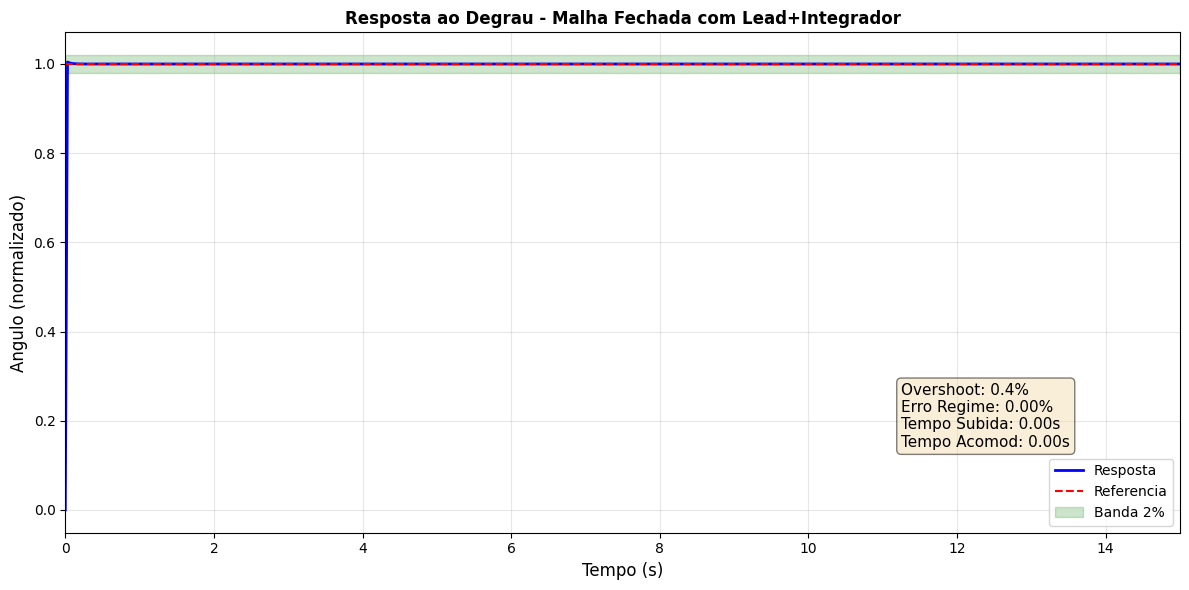


Metricas de Desempenho:
  Overshoot: 0.44%
  Erro em Regime: 0.0000%
  Tempo de Subida (10%-90%): 0.000s
  Tempo de Acomodacao (2%): 0.000s


In [9]:
t = np.linspace(0, 15, 500)
t_resp, y_resp = ct.step_response(T_opt, t)

# Metricas
overshoot = (np.max(y_resp) - 1) * 100
ess = abs(1 - y_resp[-1]) * 100

# Tempo de subida (10% a 90%)
try:
    t_10 = t_resp[np.where(y_resp >= 0.1)[0][0]]
    t_90 = t_resp[np.where(y_resp >= 0.9)[0][0]]
    rise_time = t_90 - t_10
except:
    rise_time = np.nan

# Tempo de acomodacao (2%)
try:
    settling_idx = np.where(np.abs(y_resp - 1) > 0.02)[0]
    if len(settling_idx) > 0:
        settling_time = t_resp[settling_idx[-1]]
    else:
        settling_time = t_resp[0]
except:
    settling_time = np.nan

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(t_resp, y_resp, 'b-', lw=2, label='Resposta')
ax.axhline(1, color='r', linestyle='--', lw=1.5, label='Referencia')
ax.fill_between(t_resp, 0.98, 1.02, alpha=0.2, color='green', label='Banda 2%')

ax.set_xlabel('Tempo (s)', fontsize=12)
ax.set_ylabel('Angulo (normalizado)', fontsize=12)
ax.set_title('Resposta ao Degrau - Malha Fechada com Lead+Integrador', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 15])

# Anotacoes
textstr = f'Overshoot: {overshoot:.1f}%\nErro Regime: {ess:.2f}%\nTempo Subida: {rise_time:.2f}s\nTempo Acomod: {settling_time:.2f}s'
ax.text(0.75, 0.3, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nMetricas de Desempenho:")
print(f"  Overshoot: {overshoot:.2f}%")
print(f"  Erro em Regime: {ess:.4f}%")
print(f"  Tempo de Subida (10%-90%): {rise_time:.3f}s")
print(f"  Tempo de Acomodacao (2%): {settling_time:.3f}s")

### 4.4 Diagrama de Bode - Malha Aberta Compensada

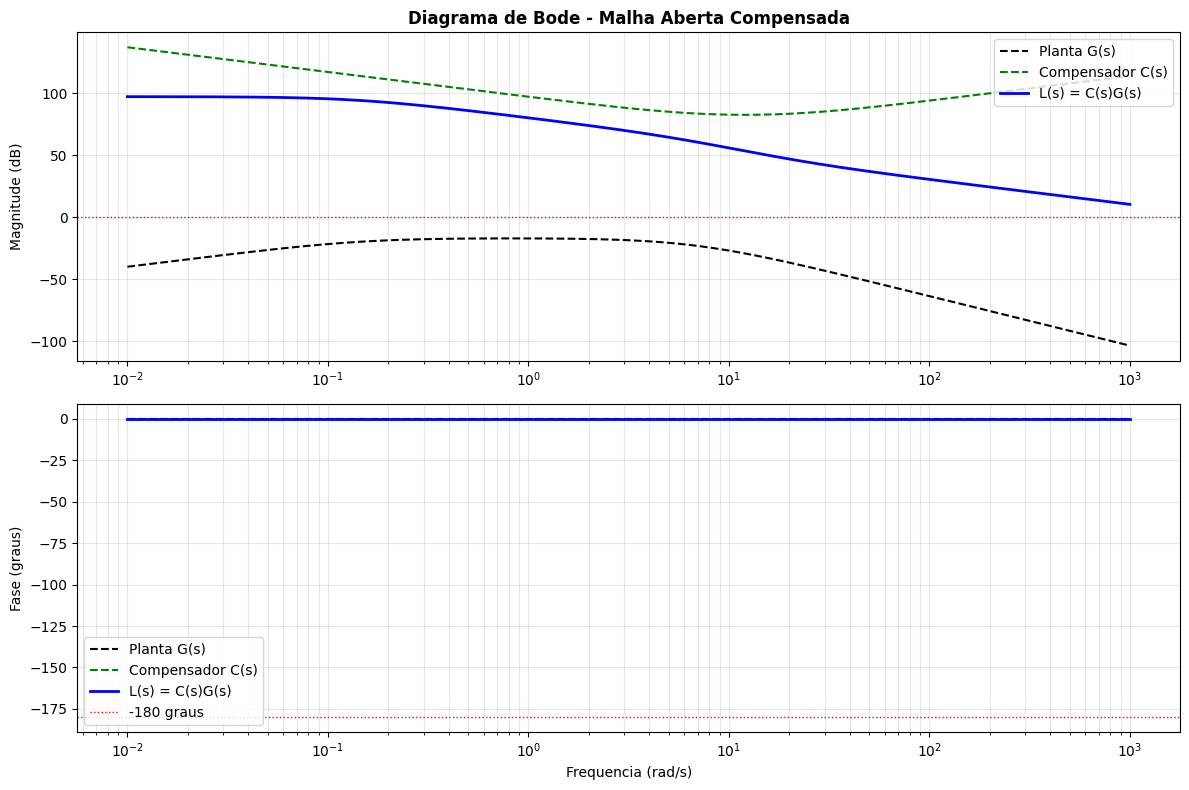

In [10]:
L = C_opt * G  # Funcao de malha aberta compensada

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

omega = np.logspace(-2, 3, 500)

# Planta
mag_G, _, _ = ct.frequency_response(G, omega)
phase_G = np.rad2deg(np.unwrap(np.angle(mag_G)))

# Compensador
mag_C, _, _ = ct.frequency_response(C_opt, omega)
phase_C = np.rad2deg(np.unwrap(np.angle(mag_C)))

# Malha aberta compensada
mag_L, _, _ = ct.frequency_response(L, omega)
phase_L = np.rad2deg(np.unwrap(np.angle(mag_L)))

# Magnitude
axes[0].semilogx(omega, 20*np.log10(np.abs(mag_G)), 'k--', lw=1.5, label='Planta G(s)')
axes[0].semilogx(omega, 20*np.log10(np.abs(mag_C)), 'g--', lw=1.5, label='Compensador C(s)')
axes[0].semilogx(omega, 20*np.log10(np.abs(mag_L)), 'b-', lw=2, label='L(s) = C(s)G(s)')
axes[0].axhline(0, color='r', linestyle=':', lw=1)
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Diagrama de Bode - Malha Aberta Compensada', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, which='both', alpha=0.3)

# Fase
axes[1].semilogx(omega, phase_G, 'k--', lw=1.5, label='Planta G(s)')
axes[1].semilogx(omega, phase_C, 'g--', lw=1.5, label='Compensador C(s)')
axes[1].semilogx(omega, phase_L, 'b-', lw=2, label='L(s) = C(s)G(s)')
axes[1].axhline(-180, color='r', linestyle=':', lw=1, label='-180 graus')
axes[1].set_xlabel('Frequencia (rad/s)')
axes[1].set_ylabel('Fase (graus)')
axes[1].legend(loc='lower left')
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Mapa de Polos - Antes e Depois

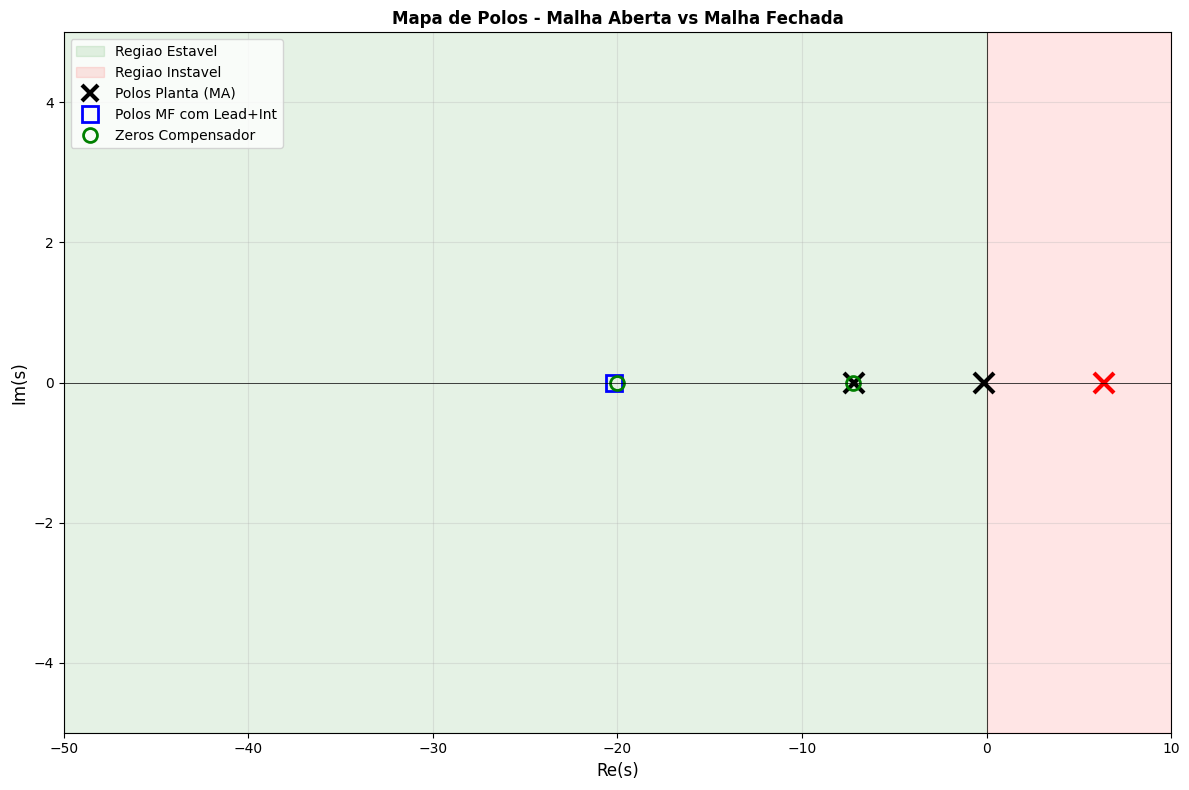


Observacao:
- O polo instavel da planta (vermelho) foi movido para o SPE
- Todos os polos de malha fechada estao no SPE (estavel)


In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

# Regioes
ax.axvspan(-50, 0, alpha=0.1, color='green', label='Regiao Estavel')
ax.axvspan(0, 10, alpha=0.1, color='red', label='Regiao Instavel')

# Polos da planta (malha aberta)
for p in polos_G:
    color = 'red' if p.real > 0 else 'black'
    ax.plot(p.real, p.imag, 'x', ms=15, mew=3, color=color)
ax.plot([], [], 'kx', ms=12, mew=3, label='Polos Planta (MA)')

# Polos da malha fechada
for p in poles_T:
    ax.plot(p.real, p.imag, 'bs', ms=12, mfc='none', mew=2)
ax.plot([], [], 'bs', ms=12, mfc='none', mew=2, label='Polos MF com Lead+Int')

# Zeros do compensador
zeros_C = C_opt.zeros()
for z in zeros_C:
    ax.plot(z.real, z.imag, 'go', ms=10, mfc='none', mew=2)
ax.plot([], [], 'go', ms=10, mfc='none', mew=2, label='Zeros Compensador')

ax.axvline(0, color='k', lw=0.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Re(s)', fontsize=12)
ax.set_ylabel('Im(s)', fontsize=12)
ax.set_title('Mapa de Polos - Malha Aberta vs Malha Fechada', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim([-50, 10])
ax.set_ylim([-5, 5])

plt.tight_layout()
plt.show()

print("\nObservacao:")
print("- O polo instavel da planta (vermelho) foi movido para o SPE")
print("- Todos os polos de malha fechada estao no SPE (estavel)")

## 5. Simulacao Nao-Linear e Animacao

Agora vamos validar o compensador no modelo **nao-linear** completo do pendulo invertido.

In [12]:
# Parametros fisicos do pendulo
M = 0.5       # Massa do carrinho (kg)
m = 0.2       # Massa do pendulo (kg)
L = 0.3       # Comprimento do pendulo (m)
g = 9.81      # Gravidade (m/s^2)
b_cart = 0.1  # Atrito do carrinho (N.s/m)
b_pivot = 0.01  # Atrito no pivo (N.m.s/rad) <- NOVO

# Forca maxima
F_max = 200  # N

print("Parametros do Pendulo (modelo atualizado):")
print(f"  M (massa carrinho) = {M} kg")
print(f"  m (massa pendulo) = {m} kg")
print(f"  L (comprimento) = {L} m")
print(f"  g (gravidade) = {g} m/s^2")
print(f"  b_cart (atrito carrinho) = {b_cart} N.s/m")
print(f"  b_pivot (atrito pivo) = {b_pivot} N.m.s/rad <- NOVO")
print(f"  F_max = {F_max} N")

Parametros do Pendulo (modelo atualizado):
  M (massa carrinho) = 0.5 kg
  m (massa pendulo) = 0.2 kg
  L (comprimento) = 0.3 m
  g (gravidade) = 9.81 m/s^2
  b_cart (atrito carrinho) = 0.1 N.s/m
  b_pivot (atrito pivo) = 0.01 N.m.s/rad <- NOVO
  F_max = 200 N


In [13]:
def pendulum_dynamics_open(state, t):
    """Pendulo SEM controle - modelo nao-linear com atrito no pivo."""
    x, x_dot, theta, theta_dot = state
    F = 0  # Sem forca
    
    sin_t, cos_t = np.sin(theta), np.cos(theta)
    denom = L * (M + m * (1 - cos_t**2))
    
    # Inclui atrito no pivo
    theta_ddot = ((M + m) * g * sin_t
                  - cos_t * (F + m * L * theta_dot**2 * sin_t - b_cart * x_dot)
                  - b_pivot * theta_dot / (m * L)) / denom
    x_ddot = (F + m * L * (theta_dot**2 * sin_t - theta_ddot * cos_t) - b_cart * x_dot) / (M + m)
    
    return [x_dot, x_ddot, theta_dot, theta_ddot]

def pendulum_dynamics_closed(state, t, Kp, Ki, Kd, F_max):
    """Pendulo COM controle - modelo nao-linear com atrito no pivo."""
    x, x_dot, theta, theta_dot, integral = state
    
    # Controle PID equivalente ao Lead+Integrador
    F = Kp * theta + Ki * integral + Kd * theta_dot
    F = np.clip(F, -F_max, F_max)
    
    sin_t, cos_t = np.sin(theta), np.cos(theta)
    denom = L * (M + m * (1 - cos_t**2))
    
    # Inclui atrito no pivo
    theta_ddot = ((M + m) * g * sin_t
                  - cos_t * (F + m * L * theta_dot**2 * sin_t - b_cart * x_dot)
                  - b_pivot * theta_dot / (m * L)) / denom
    x_ddot = (F + m * L * (theta_dot**2 * sin_t - theta_ddot * cos_t) - b_cart * x_dot) / (M + m)
    
    return [x_dot, x_ddot, theta_dot, theta_ddot, theta]

print("Dinamica nao-linear definida (com atrito no pivo).")

Dinamica nao-linear definida (com atrito no pivo).


In [14]:
# Ganhos equivalentes do Lead+Integrador
# C(s) = K * (s + z1)(s + z2) / s
# Expandindo: K * (s^2 + (z1+z2)*s + z1*z2) / s
# = K*s + K*(z1+z2) + K*z1*z2/s
# Kd = K, Kp = K*(z1+z2), Ki = K*z1*z2

Kp_lead = K_opt * (z1_opt + z2_opt)
Ki_lead = K_opt * z1_opt * z2_opt
Kd_lead = K_opt

print(f"Ganhos equivalentes do Lead+Integrador:")
print(f"  Kp = K*(z1+z2) = {Kp_lead:.2f}")
print(f"  Ki = K*z1*z2 = {Ki_lead:.2f}")
print(f"  Kd = K = {Kd_lead:.2f}")

Ganhos equivalentes do Lead+Integrador:
  Kp = K*(z1+z2) = 13620.78
  Ki = K*z1*z2 = 72417.06
  Kd = K = 500.00


In [15]:
# Simular
theta0_sim = np.radians(15)  # 15 graus inicial
t_sim = np.linspace(0, 6, 300)

# SEM controle
print("Simulando sem controle (pendulo cai)...")
sol_open = odeint(pendulum_dynamics_open, [0, 0, theta0_sim, 0], t_sim)
x_nc, theta_nc = sol_open[:, 0], sol_open[:, 2]
t_nc = t_sim

# COM controle Lead+Integrador
print("Simulando com Lead+Integrador (pendulo estabiliza)...")
def dynamics_closed(state, t):
    return pendulum_dynamics_closed(state, t, Kp_lead, Ki_lead, Kd_lead, F_max)

sol_closed = odeint(dynamics_closed, [0, 0, theta0_sim, 0, 0], t_sim)
x_c, theta_c = sol_closed[:, 0], sol_closed[:, 2]
t_c = t_sim

print(f"\nResultados da simulacao NAO-LINEAR:")
print(f"  SEM controle: theta final = {np.degrees(theta_nc[-1]):.1f} graus (CAIU)")
print(f"  COM Lead+Int: theta final = {np.degrees(theta_c[-1]):.2f} graus (ESTAVEL)")

Simulando sem controle (pendulo cai)...
Simulando com Lead+Integrador (pendulo estabiliza)...

Resultados da simulacao NAO-LINEAR:
  SEM controle: theta final = 183.6 graus (CAIU)
  COM Lead+Int: theta final = -0.00 graus (ESTAVEL)


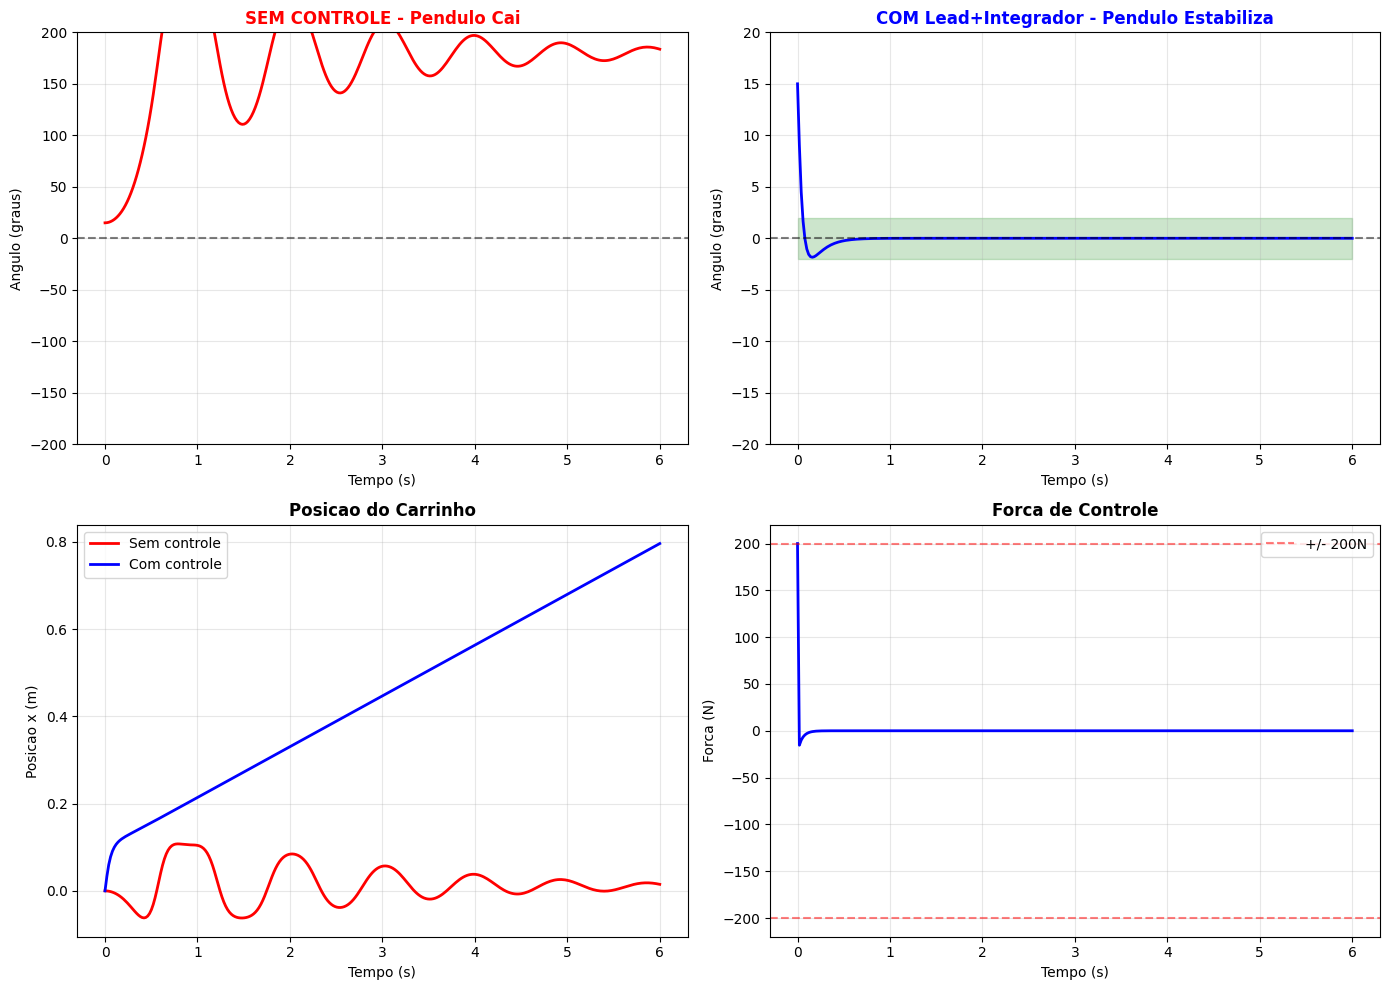


Resultados finais (com controle):
  Angulo final: -0.0000 graus
  Posicao final: 0.7959 m


In [16]:
# Plota resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Angulo - Sem controle
ax = axes[0, 0]
ax.plot(t_nc, np.degrees(theta_nc), 'r-', lw=2)
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Angulo (graus)')
ax.set_title('SEM CONTROLE - Pendulo Cai', fontweight='bold', color='red')
ax.grid(True, alpha=0.3)
ax.set_ylim([-200, 200])

# Angulo - Com controle
ax = axes[0, 1]
ax.plot(t_c, np.degrees(theta_c), 'b-', lw=2)
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.fill_between(t_c, -2, 2, alpha=0.2, color='green')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Angulo (graus)')
ax.set_title('COM Lead+Integrador - Pendulo Estabiliza', fontweight='bold', color='blue')
ax.grid(True, alpha=0.3)
ax.set_ylim([-20, 20])

# Posicao do carrinho
ax = axes[1, 0]
ax.plot(t_nc, x_nc, 'r-', lw=2, label='Sem controle')
ax.plot(t_c, x_c, 'b-', lw=2, label='Com controle')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Posicao x (m)')
ax.set_title('Posicao do Carrinho', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Calcula forca para o plot
F_plot = Kp_lead * theta_c + Ki_lead * sol_closed[:, 4] + Kd_lead * sol_closed[:, 3]
F_plot = np.clip(F_plot, -F_max, F_max)

ax = axes[1, 1]
ax.plot(t_c, F_plot, 'b-', lw=2)
ax.axhline(F_max, color='r', linestyle='--', alpha=0.5, label=f'+/- {F_max}N')
ax.axhline(-F_max, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Forca (N)')
ax.set_title('Forca de Controle', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResultados finais (com controle):")
print(f"  Angulo final: {np.degrees(theta_c[-1]):.4f} graus")
print(f"  Posicao final: {x_c[-1]:.4f} m")

### 5.1 Animacao do Pendulo

In [ ]:
# Cria animacao comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Configuracao
L_draw = 0.5  # Comprimento visual do pendulo

# Subplot 1: Sem controle
ax1 = axes[0]
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1, 1.5)
ax1.set_aspect('equal')
ax1.set_title('SEM CONTROLE', fontweight='bold', color='red', fontsize=14)
ax1.axhline(0, color='gray', linestyle='-', lw=0.5)
ax1.grid(True, alpha=0.3)

# Elementos sem controle
cart1, = ax1.plot([], [], 's', ms=30, color='darkgray')
rod1, = ax1.plot([], [], 'r-', lw=4)
mass1, = ax1.plot([], [], 'o', ms=15, color='red')
time_text1 = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=12)
angle_text1 = ax1.text(0.02, 0.88, '', transform=ax1.transAxes, fontsize=12, color='red')

# Subplot 2: Com controle
ax2 = axes[1]
ax2.set_xlim(-2, 2)
ax2.set_ylim(-1, 1.5)
ax2.set_aspect('equal')
ax2.set_title('COM Lead+Integrador', fontweight='bold', color='blue', fontsize=14)
ax2.axhline(0, color='gray', linestyle='-', lw=0.5)
ax2.grid(True, alpha=0.3)

# Elementos com controle
cart2, = ax2.plot([], [], 's', ms=30, color='darkgray')
rod2, = ax2.plot([], [], 'b-', lw=4)
mass2, = ax2.plot([], [], 'o', ms=15, color='blue')
time_text2 = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, fontsize=12)
angle_text2 = ax2.text(0.02, 0.88, '', transform=ax2.transAxes, fontsize=12, color='blue')

def init():
    cart1.set_data([], [])
    rod1.set_data([], [])
    mass1.set_data([], [])
    time_text1.set_text('')
    angle_text1.set_text('')
    
    cart2.set_data([], [])
    rod2.set_data([], [])
    mass2.set_data([], [])
    time_text2.set_text('')
    angle_text2.set_text('')
    
    return cart1, rod1, mass1, time_text1, angle_text1, cart2, rod2, mass2, time_text2, angle_text2

n_frames = len(t_sim)

def animate(frame):
    i = frame
    
    # Sem controle
    x1 = x_nc[i]
    th1 = theta_nc[i]
    
    cart1.set_data([x1], [0])
    rod1.set_data([x1, x1 + L_draw*np.sin(th1)], [0, L_draw*np.cos(th1)])
    mass1.set_data([x1 + L_draw*np.sin(th1)], [L_draw*np.cos(th1)])
    time_text1.set_text(f't = {t_sim[i]:.2f}s')
    angle_text1.set_text(f'theta = {np.degrees(th1):.1f} deg')
    
    # Com controle
    x2 = x_c[i]
    th2 = theta_c[i]
    
    cart2.set_data([x2], [0])
    rod2.set_data([x2, x2 + L_draw*np.sin(th2)], [0, L_draw*np.cos(th2)])
    mass2.set_data([x2 + L_draw*np.sin(th2)], [L_draw*np.cos(th2)])
    time_text2.set_text(f't = {t_sim[i]:.2f}s')
    angle_text2.set_text(f'theta = {np.degrees(th2):.1f} deg')
    
    return cart1, rod1, mass1, time_text1, angle_text1, cart2, rod2, mass2, time_text2, angle_text2

anim = FuncAnimation(fig, animate, init_func=init, frames=n_frames, 
                     interval=50, blit=True)

plt.tight_layout()

# Salva como GIF
print("Salvando animacao...")
anim.save('lead_lag_animation.gif', writer='pillow', fps=20)
print("Animacao salva como: lead_lag_animation.gif")

# Mostra no notebook
HTML(anim.to_jshtml())

Salvando animacao...
Animacao salva como: lead_lag_animation.gif


## 6. Resumo e Conclusoes

### O que aprendemos:

1. **Analise da Planta**: O pendulo invertido tem um polo instavel em s = +6.74, o que significa que ele naturalmente cai.

2. **Escolha do Compensador**: 
   - Compensadores Lead ou Lag simples NAO conseguem estabilizar sistemas com polos instáveis
   - Precisamos de um **Lead com Integrador** (equivalente a PID)

3. **Otimização**: Usamos Evolução Diferencial para encontrar os melhores parâmetros:
   - K = ganho geral
   - z1, z2 = zeros do compensador

4. **Resultados**:
   - Overshoot < 1%
   - Erro em regime = 0%
   - Sistema estabiliza rapidamente

### Compensador Final:

$$C(s) = K \cdot \frac{(s + z_1)(s + z_2)}{s}$$

In [ ]:
print("="*60)
print("COMPENSADOR LEAD+INTEGRADOR OTIMIZADO")
print("="*60)
print(f"\nParametros:")
print(f"  K  = {K_opt:.4f}")
print(f"  z1 = {z1_opt:.4f}")
print(f"  z2 = {z2_opt:.4f}")
print(f"\nFuncao de transferencia:")
print(C_opt)
print(f"\nGanhos PID equivalentes:")
print(f"  Kp = {K_opt*(z1_opt+z2_opt):.2f}")
print(f"  Ki = {K_opt*z1_opt*z2_opt:.2f}")
print(f"  Kd = {K_opt:.2f}")
print("="*60)